In [1]:
import os

# Force pure‑Python protobuf implementation before any other imports
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Attempt to import TensorFlow; if it fails we will skip TF‑related parts
try:
    import tensorflow as tf
    from tensorflow.keras import applications
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.layers import (
        Dense,
        Dropout,
        BatchNormalization,
        GlobalAveragePooling2D,
    )
except Exception as e:
    tf = None
    print("TensorFlow import failed; continuing without TF-dependent functionality.")


def abs_path(*parts):
    return os.path.abspath(os.path.join(*parts))




2026-05-19 10:06:00.715695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779185160.729705      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779185160.734156      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 10:06:00.753043: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
train_csv_path = abs_path(
    "..", "input", "cassava-leaf-disease-classification", "train.csv"
)
label_json_path = abs_path(
    "..",
    "input",
    "cassava-leaf-disease-classification",
    "label_num_to_disease_map.json",
)
images_dir_path = abs_path(
    "..", "input", "cassava-leaf-disease-classification", "train_images"
)




In [3]:
train_csv = pd.read_csv(train_csv_path)
train_csv["label"] = train_csv["label"].astype("string")

label_class = pd.read_json(label_json_path, orient="index")
label_class = label_class.values.flatten().tolist()




In [4]:
print("Label names :")
for i, label in enumerate(label_class):
    print(f" {i}. {label}")




Label names :
 0. Cassava Bacterial Blight (CBB)
 1. Cassava Brown Streak Disease (CBSD)
 2. Cassava Green Mottle (CGM)
 3. Cassava Mosaic Disease (CMD)
 4. Healthy


In [5]:
BATCH_SIZE = 24
IMG_SIZE = 320




In [6]:
if tf is not None:
    train_gen = ImageDataGenerator(
        rotation_range=270,
        width_shift_range=0.2,
        height_shift_range=0.2,
        brightness_range=[0.1, 0.9],
        shear_range=25,
        zoom_range=0.3,
        channel_shift_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
        rescale=1 / 255,
        validation_split=0.2,
    )

    valid_gen = ImageDataGenerator(rescale=1 / 255, validation_split=0.2)
else:
    train_gen = valid_gen = None




In [7]:
if tf is not None:
    train_generator = train_gen.flow_from_dataframe(
        dataframe=train_csv,
        directory=images_dir_path,
        x_col="image_id",
        y_col="label",
        target_size=(IMG_SIZE, IMG_SIZE),
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=True,
        subset="training",
    )

    valid_generator = valid_gen.flow_from_dataframe(
        dataframe=train_csv,
        directory=images_dir_path,
        x_col="image_id",
        y_col="label",
        target_size=(IMG_SIZE, IMG_SIZE),
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        shuffle=False,
        subset="validation",
    )
else:
    train_generator = valid_generator = None




Found 14977 validated image filenames belonging to 5 classes.
Found 3744 validated image filenames belonging to 5 classes.


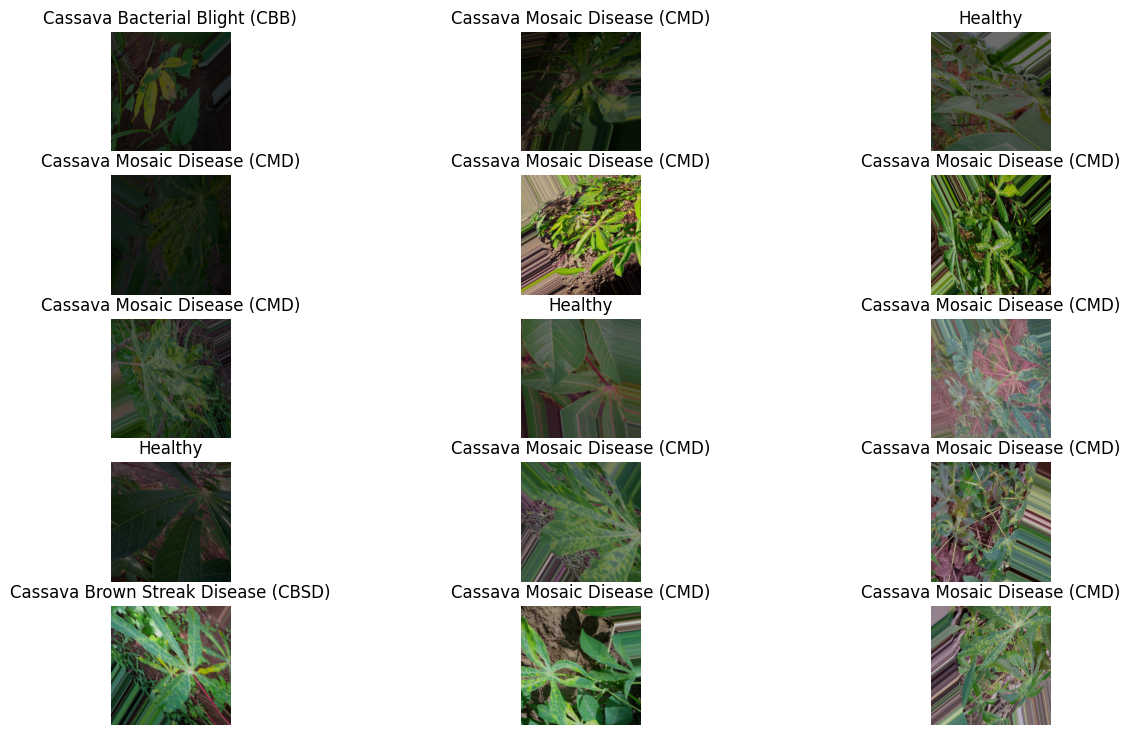

In [8]:
if tf is not None:
    batch = next(train_generator)
    images = batch[0]
    labels = batch[1]

    plt.figure(figsize=(15, 9))
    for i, (img, label) in enumerate(zip(images, labels)):
        plt.subplot(5, 3, i % 15 + 1)
        plt.axis("off")
        plt.imshow(img)
        plt.title(label_class[np.argmax(label)])
        if i == 14:
            break
    plt.show()
else:
    print("Skipping image preview (TensorFlow not available).")




In [9]:
if tf is not None:
    base = applications.InceptionResNetV2(
        include_top=False, weights="imagenet", input_shape=[IMG_SIZE, IMG_SIZE, 3]
    )
else:
    base = None




2026-05-19 10:06:09.094304: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1779185169.094752      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
if tf is not None:
    model = tf.keras.Sequential()
    model.add(base)
    model.add(BatchNormalization(axis=-1))
    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation="relu"))
    model.add(Dense(5, activation="softmax"))

    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        metrics=["acc", tf.keras.metrics.TruePositives(name="tp")],
    )
else:
    model = None




In [11]:
if tf is not None:

    def scheduler(epoch, lr):
        if epoch > 3 and epoch % 2 == 0:
            return lr / 1.25
        return lr

    callback0 = tf.keras.callbacks.ModelCheckpoint(
        "./CasavaLeafDiseaseModel.h5", monitor="val_loss", save_best_only=True
    )
    callback1 = tf.keras.callbacks.LearningRateScheduler(scheduler)
else:
    scheduler = None
    callback0 = callback1 = None




In [12]:
if tf is not None:
    try:
        model = tf.keras.models.load_model(
            abs_path(
                "..",
                "input",
                "casavaleafdiseasemodel-tf",
                "CasavaLeafDiseaseModel_epoch_12_acc_85.h5",
            )
        )
        print("Loaded pretrained model.")
    except Exception:
        print("No saved model found – proceeding with the freshly initialized model.")
else:
    print("Skipping model loading (TensorFlow not available).")




No saved model found – proceeding with the freshly initialized model.


In [13]:
test_img_path = abs_path(
    "..",
    "input",
    "cassava-leaf-disease-classification",
    "test_images",
    "2216849948.jpg",
)

img = cv2.imread(test_img_path)
if img is not None:
    resized_img = (
        cv2.resize(img, (IMG_SIZE, IMG_SIZE)).reshape(-1, IMG_SIZE, IMG_SIZE, 3) / 255
    )
    plt.figure(figsize=(8, 4))
    plt.title("TEST IMAGE")
    plt.imshow(resized_img[0])
    plt.show()
else:
    print(f"Warning: could not read test image at {test_img_path}. Skipping preview.")




[ WARN:0@14.333] global loadsave.cpp:275 findDecoder imread_('/kaggle/input/cassava-leaf-disease-classification/test_images/2216849948.jpg'): can't open/read file: check file path/integrity


In [14]:
ss_path = abs_path(
    "..", "input", "cassava-leaf-disease-classification", "sample_submission.csv"
)
ss = pd.read_csv(ss_path)

most_common_label = train_csv["label"].mode()[0]

preds = [most_common_label] * len(ss)

my_submission = pd.DataFrame({"image_id": ss["image_id"], "label": preds})
my_submission.to_csv("submission.csv", index=False)




In [15]:
print("Submission File: \n---------------\n")
print(my_submission.head())

Submission File: 
---------------

         image_id label
0  1234294272.jpg     3
1  1234332763.jpg     3
2  1234375577.jpg     3
3  1234555380.jpg     3
4  1234571117.jpg     3
